# Análisis modular del TP1

Este notebook ejecuta el flujo de análisis por celdas y es compatible con VS Code, Jupyter y Google Colab.

**Archivo de entrada:** `datos_TP1_2025.csv`

## 1. Crear el notebook y seleccionar el kernel

En VS Code o Colab, seleccioná un kernel de Python válido antes de ejecutar las celdas. Los resultados quedarán embebidos en este archivo `.ipynb`.

## 2. Instalar y validar dependencias

Ejecutá esta celda solo si el entorno no tiene `pandas` o `matplotlib` instalados. En Google Colab normalmente ya están disponibles.

In [1]:
pip install optbinning

You should consider upgrading via the '/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from optbinning import OptimalBinning
sys.path.append(str(Path.cwd().parent))
from functions.utils import *
from functions.eda import *

## 3. Cargar los datos

La ruta relativa funciona tanto en la carpeta local del proyecto como después de subir el archivo a Colab.

In [3]:
OUTPUT_DIR = Path("outputs")

dataset = cargar_pickle("../outputs/dataset_cleaned.pkl")
dataset.head()

Archivo pickle cargado desde: /Users/diegorojas/Documents/github projects/aa-tp-1/outputs/dataset_cleaned.pkl


,Estudios_máximos_antes_de_la_inscripción,estado_civil,modo_aplicacion,sexo,desplazado,target,carrera,asistencia,cualificacion_promedio,puntaje_ingreso,...,promedio_notas_semestres,promedio_uc_inscritos_semestres,promedio_uc_aprobadas_semestres,promedio_evaluaciones_semestres,ingresos_padre_nivel,ingresos_madre_nivel,ingresos_familia_nivel,demanda_cog_padre_nivel,demanda_cog_madre_nivel,demanda_cog_familia_nivel
0,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,Graduado,Turismo,Diurna,65,61,...,66.0,6.0,5.5,7.0,1,1,1.0,1,1,1.0
1,Educación Secundaria,Soltero,Acceso por Normativa Específica,Femenino,No,Desertor,Enfermería,Diurna,67,58,...,0.0,7.0,0.0,12.5,1,1,1.0,1,1,1.0
2,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,En Curso,Gestión,Diurna,64,62,...,52.5,5.0,2.5,8.5,1,3,2.0,1,3,2.0
3,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,En Curso,Enfermería,Diurna,67,54,...,60.5,7.0,4.0,8.5,3,3,3.0,3,3,3.0
4,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,En Curso,Publicidad y Marketing,Diurna,68,62,...,63.5,6.0,6.0,7.5,5,1,3.0,5,1,3.0


In [4]:
dataset.dtypes

Estudios_máximos_antes_de_la_inscripción     object
estado_civil                                 object
modo_aplicacion                              object
sexo                                         object
desplazado                                   object
target                                       object
carrera                                      object
asistencia                                   object
cualificacion_promedio                        int64
puntaje_ingreso                               int64
necesidades_educativas_especiales            object
tiene_deuda                                  object
matricula_al_dia                             object
posee_beca                                   object
edad_inscripcion                              int64
estudiante_internacional                     object
uc_inscritos_primer_semestre                  int64
cant_eval_primer_semestre                     int64
uc_aprobadas_primer_semestre                  int64
nota_promedi

In [5]:
estadisticas_numericas = calcular_estadisticas_numericas(dataset)
estadisticas_numericas

,N,N Miss,Missing,Zeros,Positivos,Negativos,min,max,mean,p_0.01,p_0.05,p_0.25,p_0.5,p_0.75,p_0.95,p_0.99,std,Coeff of Variation
cualificacion_promedio,50000,0,0.0,0,50000,0,48.0,95.0,66.25682,51.99,58.0,62.0,67.0,70.0,75.0,80.0,5.518564,0.083291
puntaje_ingreso,50000,0,0.0,0,50000,0,48.0,95.0,62.67162,49.00,52.0,59.0,62.0,66.0,75.0,80.0,6.279323,0.100194
edad_inscripcion,50000,0,0.0,0,50000,0,17.0,70.0,22.27876,18.00,18.0,18.0,19.0,23.0,38.0,49.0,6.898876,0.309662
uc_inscritos_primer_semestre,50000,0,0.0,1745,48255,0,0.0,26.0,5.89616,0.00,5.0,5.0,6.0,6.0,8.0,12.0,1.682294,0.285320
cant_eval_primer_semestre,50000,0,0.0,5129,44871,0,0.0,45.0,7.37380,0.00,0.0,6.0,7.0,9.0,13.0,16.0,3.508242,0.475771
uc_aprobadas_primer_semestre,50000,0,0.0,10408,39592,0,0.0,26.0,4.18734,0.00,0.0,2.0,5.0,6.0,7.0,11.0,2.690619,0.642560
nota_promedio_primer_semestre,50000,0,0.0,10407,39593,0,0.0,94.0,50.03856,0.00,0.0,53.0,61.0,67.0,73.0,77.0,26.251664,0.524629
uc_inscritos_segundo_semestre,50000,0,0.0,1748,48252,0,0.0,21.0,5.93710,0.00,5.0,5.0,6.0,6.0,8.0,11.0,1.633413,0.275120
cant_eval_segundo_semestre,50000,0,0.0,5686,44314,0,0.0,33.0,7.25708,0.00,0.0,6.0,8.0,9.0,13.0,16.0,3.506086,0.483126
uc_aprobadas_segundo_semestre,50000,0,0.0,12020,37980,0,0.0,19.0,4.01412,0.00,0.0,1.0,5.0,6.0,8.0,9.0,2.773358,0.690901


In [6]:
estadisticas_categoricas = calcular_estadisticas_categoricas(dataset)
estadisticas_categoricas

,Missing,Niveles,Moda,Frec_Moda,Largo
Variable,,,,,
Estudios_máximos_antes_de_la_inscripción,0,5,Educación Secundaria,43950,50000
estado_civil,0,6,Soltero,45861,50000
modo_aplicacion,0,4,Acceso General,34694,50000
sexo,0,2,Femenino,34240,50000
desplazado,0,2,Sí,28548,50000
target,0,3,Graduado,23707,50000
carrera,0,15,Enfermería,7889,50000
asistencia,0,2,Diurna,45756,50000
necesidades_educativas_especiales,0,2,No,49808,50000


## 4. Correlación entre variables

La siguiente función calcula la matriz de correlación de las variables numéricas y puede mostrarla como mapa de calor.


In [7]:
variables_to_corr = [
    'cualificacion_promedio', 'puntaje_ingreso', 'edad_inscripcion',
    'uc_inscritos_primer_semestre', 'cant_eval_primer_semestre',
    'uc_aprobadas_primer_semestre', 'nota_promedio_primer_semestre',
    'uc_inscritos_segundo_semestre', 'cant_eval_segundo_semestre',
    'uc_aprobadas_segundo_semestre', 'nota_promedio_segundo_semestre'
]

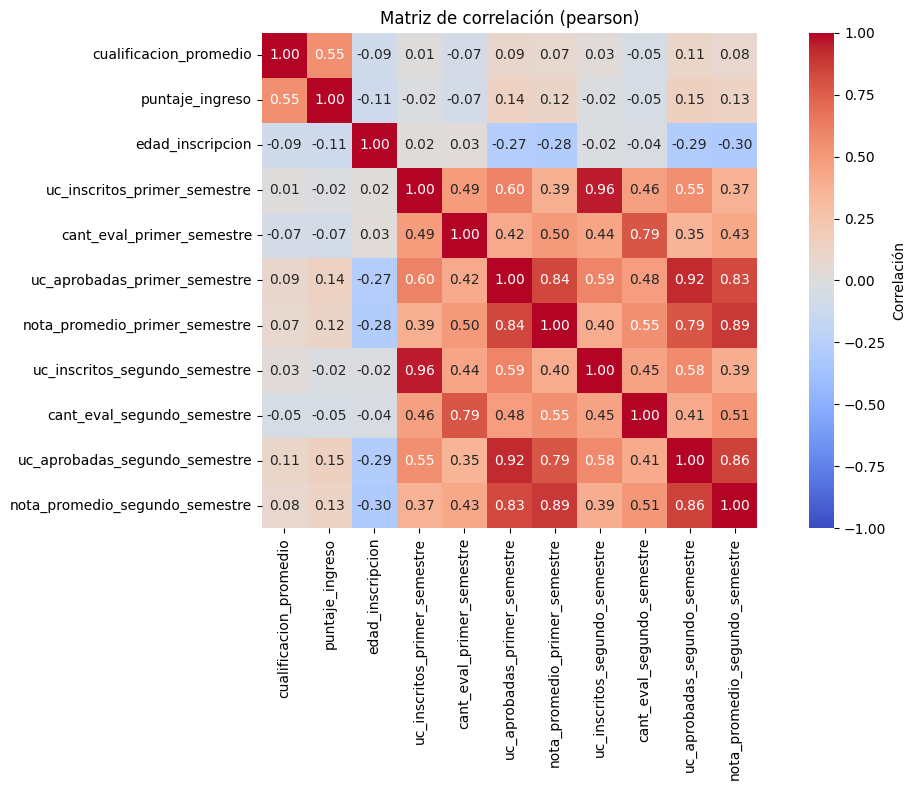

In [8]:
matriz_correlacion = calcular_correlacion(
    dataset,
    variables_to_corr,
    plot=True,
)


### Filtrar solo los estudiantes que han desertado o se han graduado

In [9]:
dataset_binario = dataset[dataset["target"].isin(["Desertor", "Graduado"])].copy()
dataset_binario["es_desercion"] = dataset_binario["target"].map({"Graduado": 0, "Desertor": 1})
dataset_binario["es_desercion"].value_counts(1)

es_desercion
0    0.589199
1    0.410801
Name: proportion, dtype: float64

## 5. Calcula de Information Value (IV)

Usamos como target la variable a predecir **es_desercion** que ya ha sido binarizada y toma los valores de 0 para los graduados y 1 para los desertores.

In [10]:
dataset_binario.columns

Index(['Estudios_máximos_antes_de_la_inscripción', 'estado_civil',
       'modo_aplicacion', 'sexo', 'desplazado', 'target', 'carrera',
       'asistencia', 'cualificacion_promedio', 'puntaje_ingreso',
       'necesidades_educativas_especiales', 'tiene_deuda', 'matricula_al_dia',
       'posee_beca', 'edad_inscripcion', 'estudiante_internacional',
       'uc_inscritos_primer_semestre', 'cant_eval_primer_semestre',
       'uc_aprobadas_primer_semestre', 'nota_promedio_primer_semestre',
       'uc_inscritos_segundo_semestre', 'cant_eval_segundo_semestre',
       'uc_aprobadas_segundo_semestre', 'nota_promedio_segundo_semestre',
       'Demanda_Cog_Padre', 'Demanda_Cog_Madre', 'Ingresos_Padre',
       'Ingresos_Madre', 'es_masculino', 'es_desplazado',
       'es_asistencia_diurna', 'es_deudor', 'es_moroso', 'es_becado',
       'es_estudiante_internacional', 'promedio_notas_semestres',
       'promedio_uc_inscritos_semestres', 'promedio_uc_aprobadas_semestres',
       'promedio_evaluacione

In [11]:
variables_to_iv = [
    'Estudios_máximos_antes_de_la_inscripción', 'estado_civil',
    'modo_aplicacion', 'sexo', 'desplazado', 'carrera',
    'asistencia', 'cualificacion_promedio', 'puntaje_ingreso',
    'necesidades_educativas_especiales', 'tiene_deuda', 'matricula_al_dia',
    'posee_beca', 'edad_inscripcion', 'estudiante_internacional',
    'uc_inscritos_primer_semestre', 'cant_eval_primer_semestre',
    'uc_aprobadas_primer_semestre', 'nota_promedio_primer_semestre',
    'uc_inscritos_segundo_semestre', 'cant_eval_segundo_semestre',
    'uc_aprobadas_segundo_semestre', 'promedio_notas_semestres',
    'promedio_uc_inscritos_semestres', 'promedio_uc_aprobadas_semestres',
    'promedio_evaluaciones_semestres', 'demanda_cog_familia_nivel', 'ingresos_familia_nivel',
    'Demanda_Cog_Padre', 'Demanda_Cog_Madre', 'Ingresos_Padre',
    'Ingresos_Madre'
]

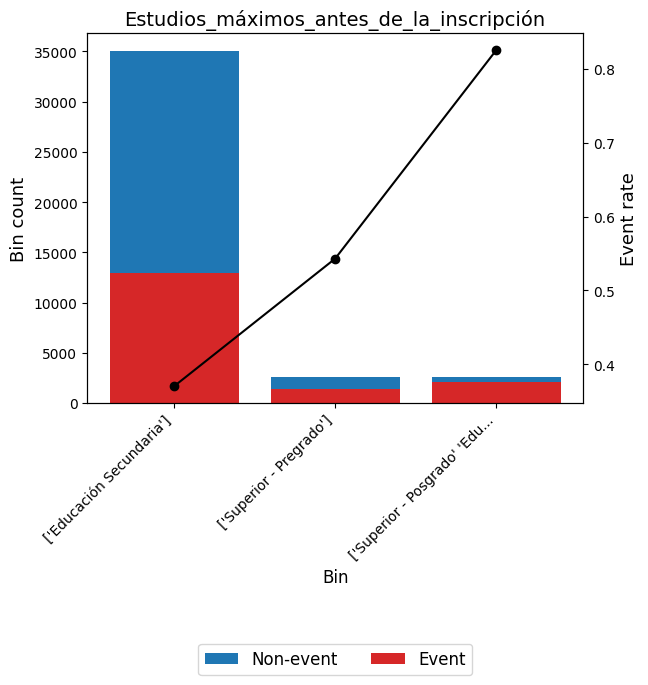

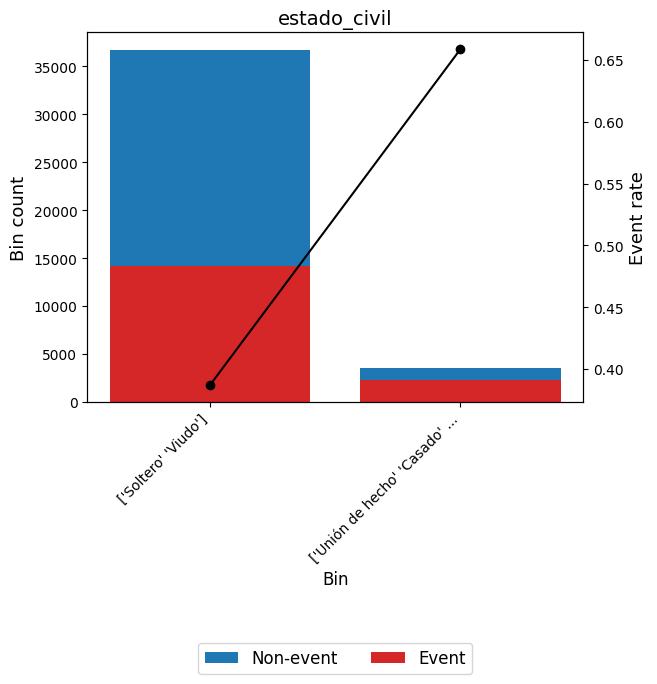

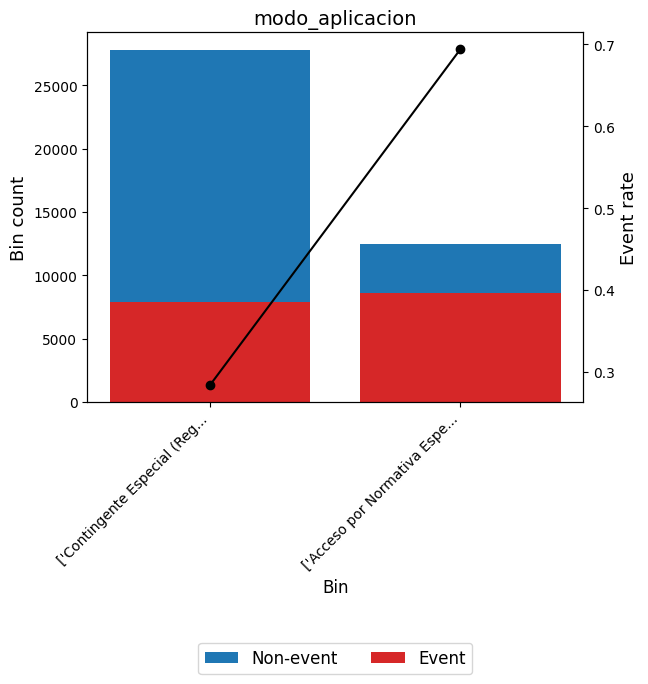

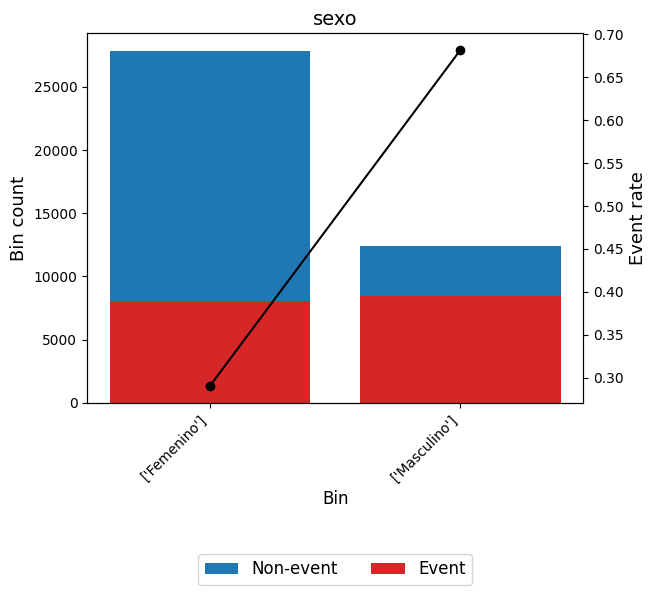

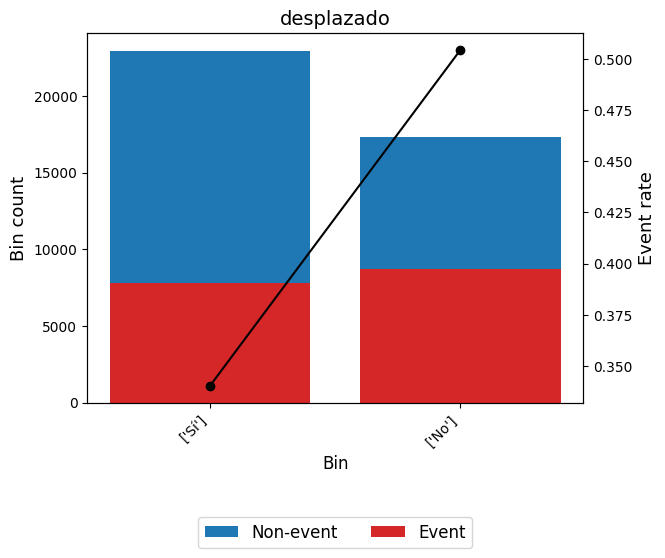

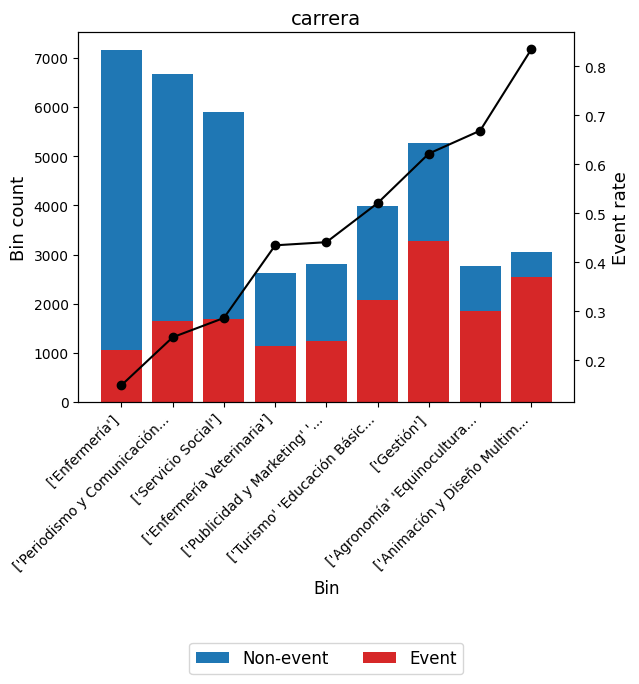

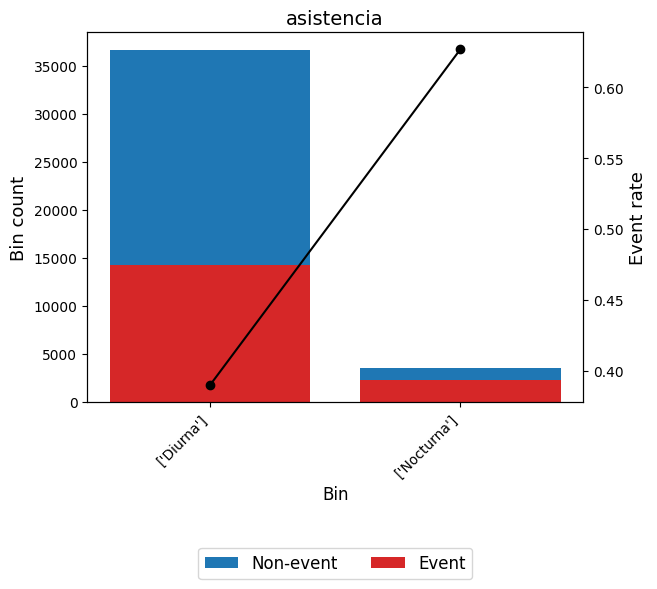

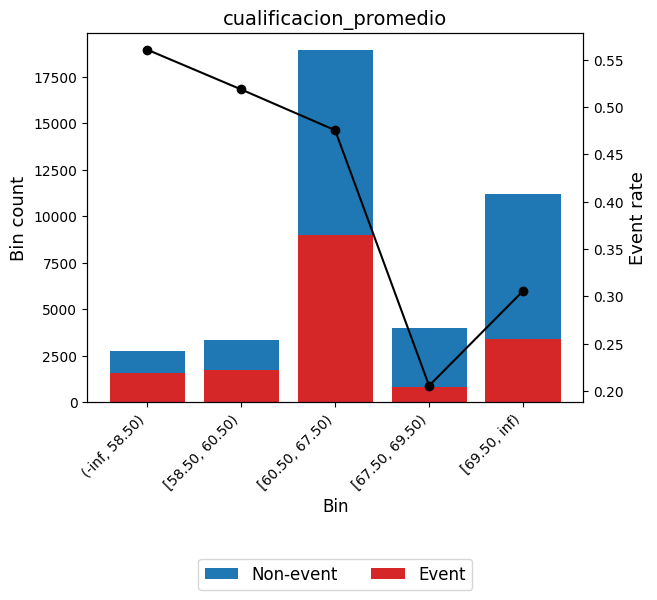

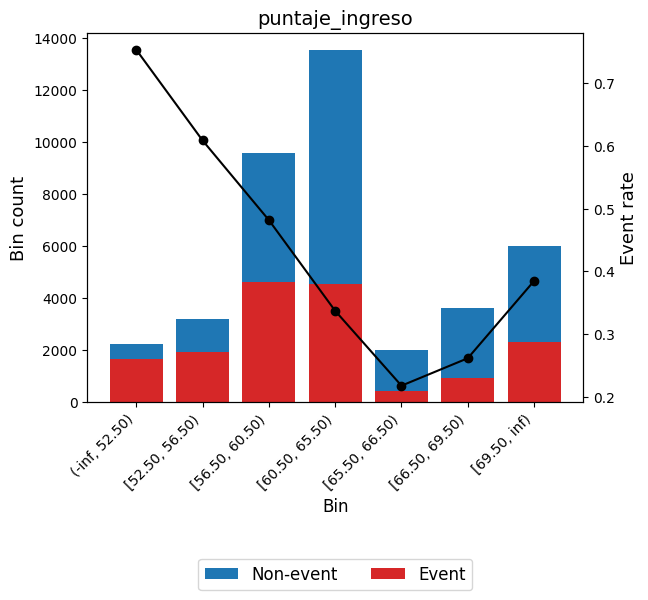

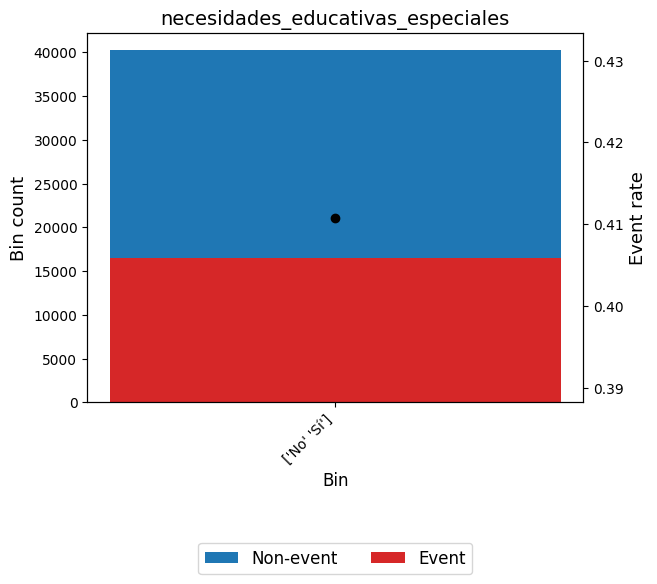

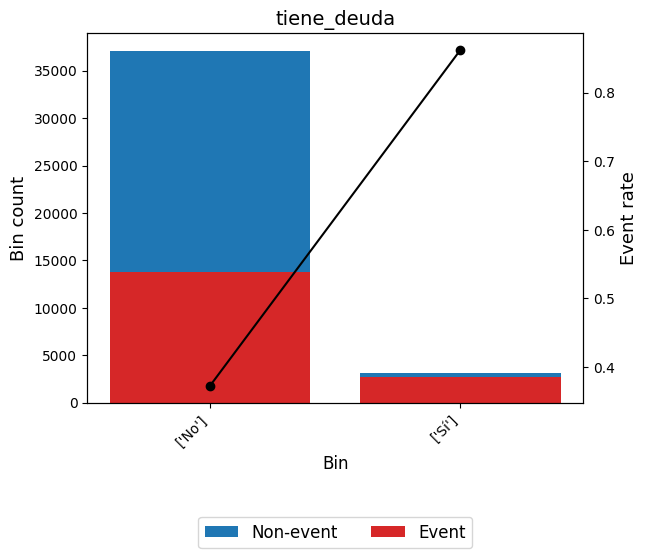

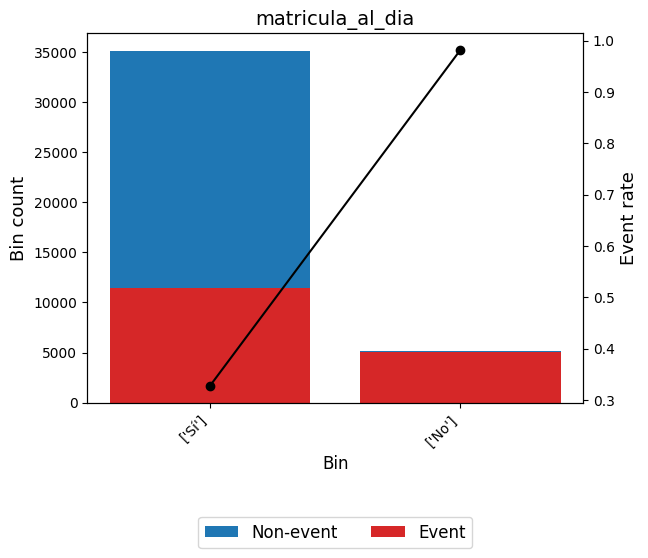

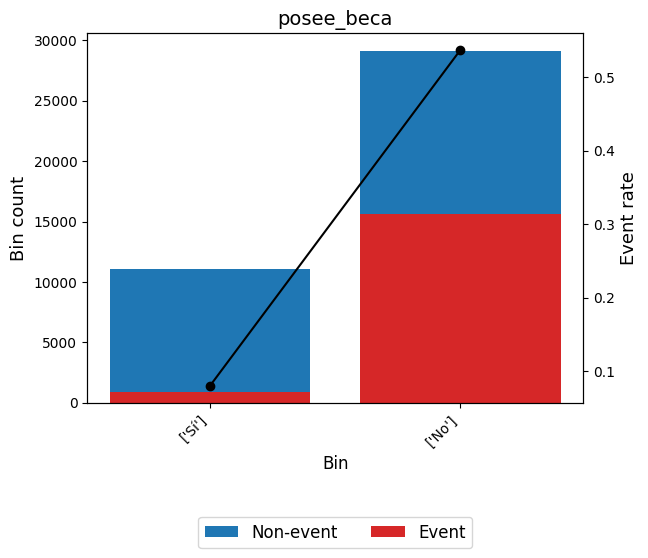

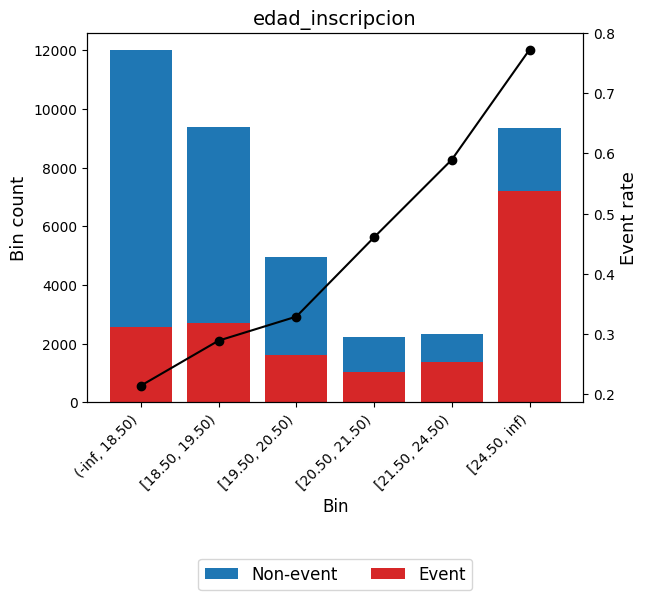

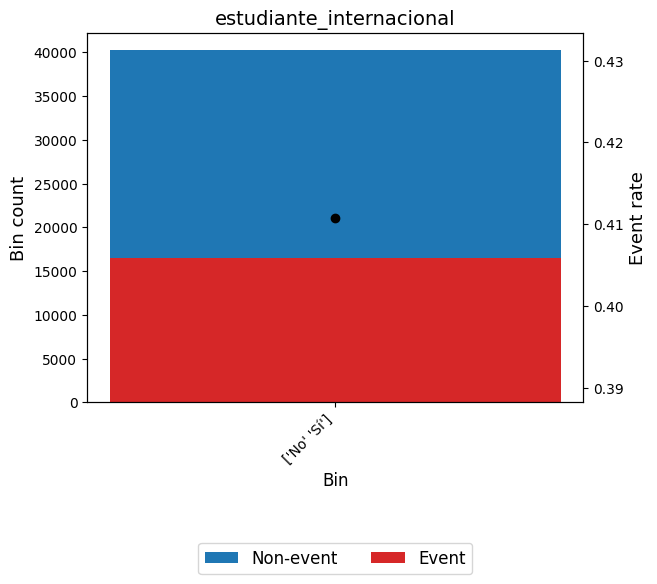

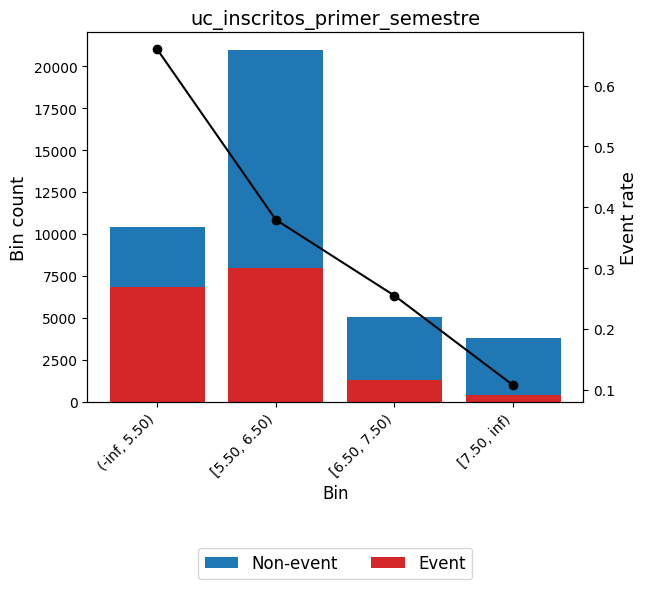

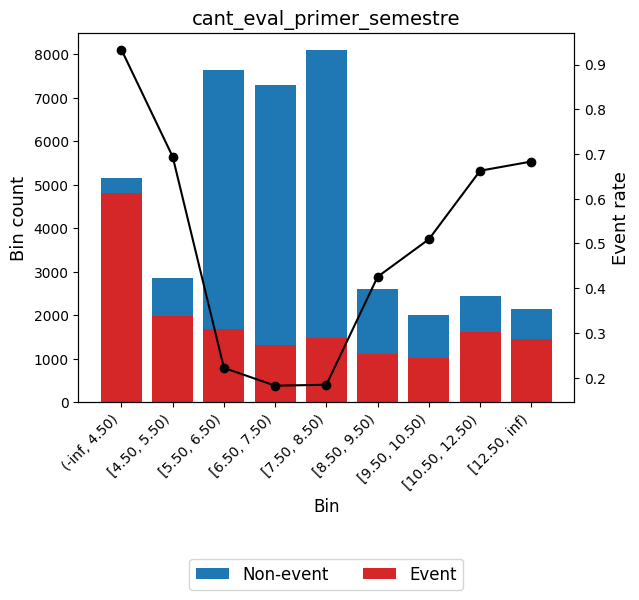

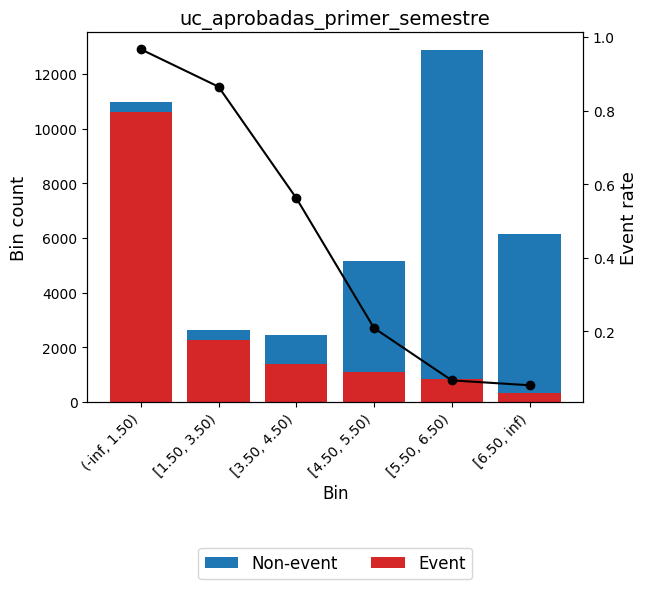

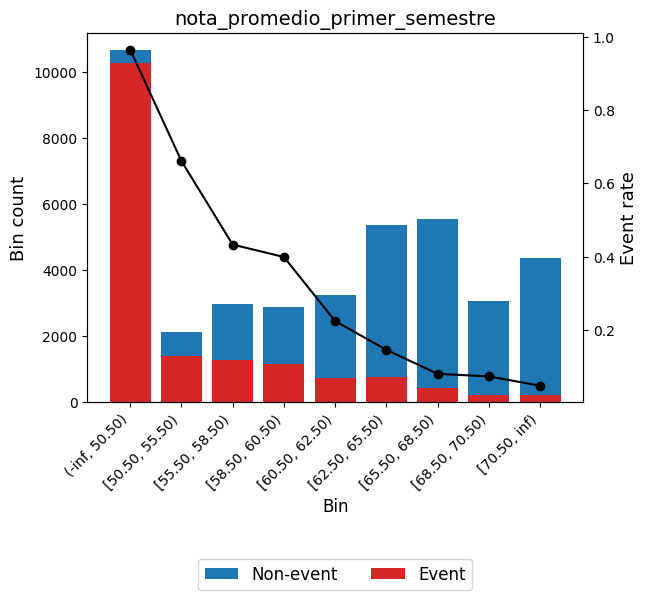

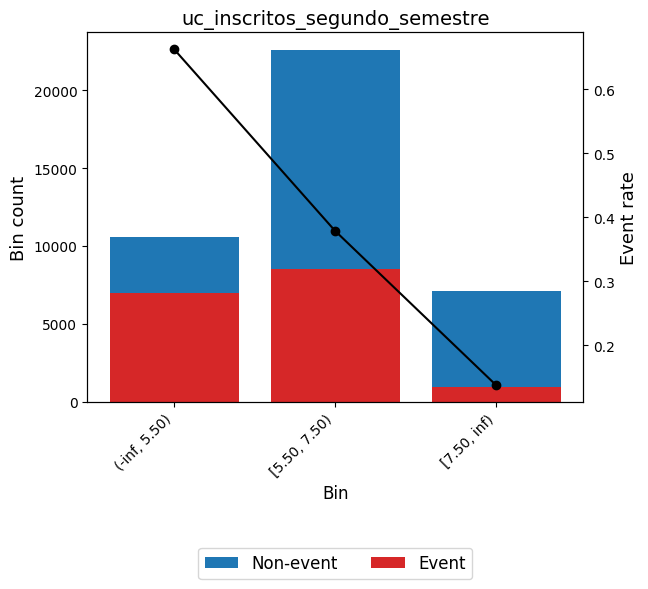

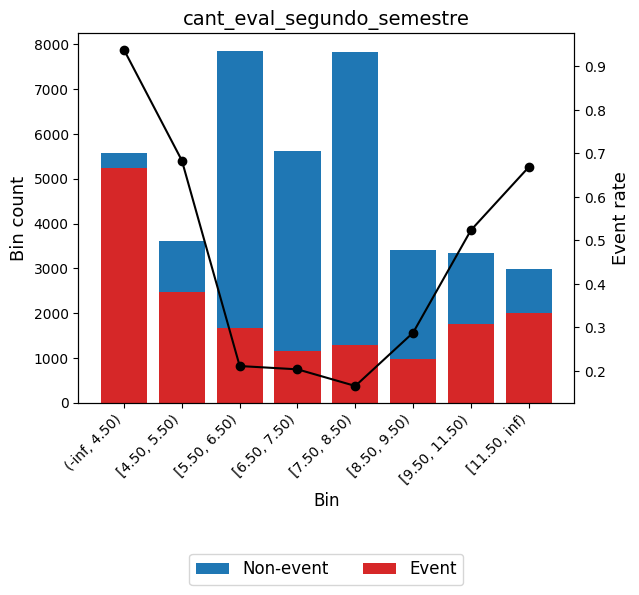

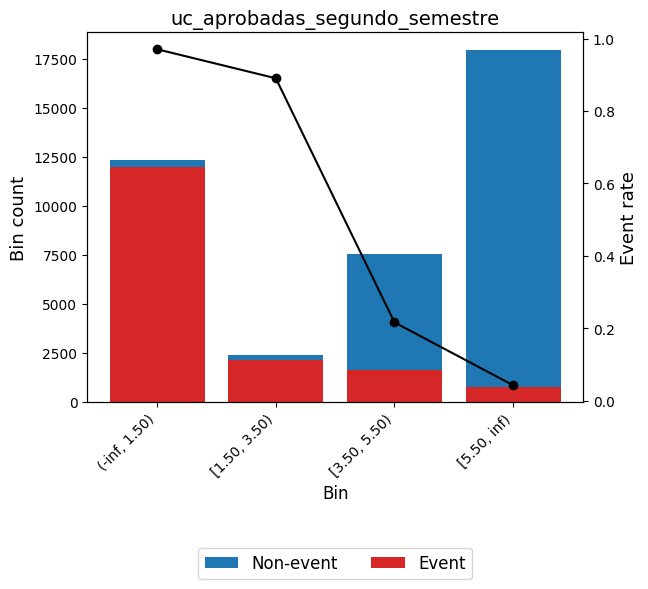

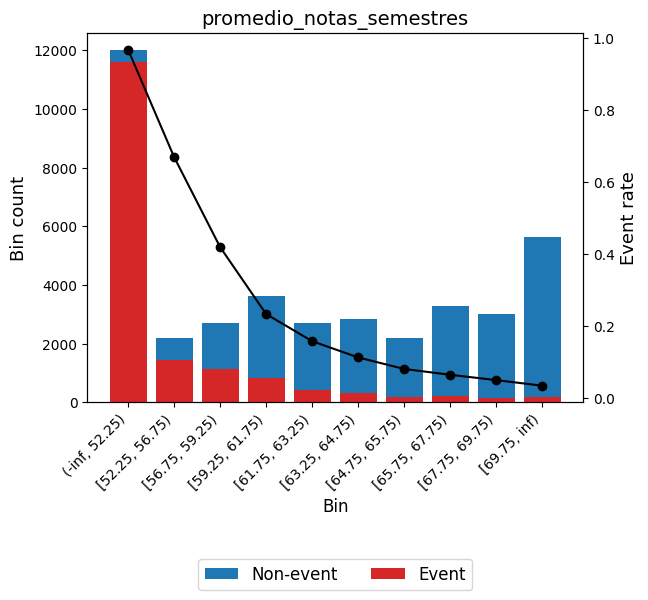

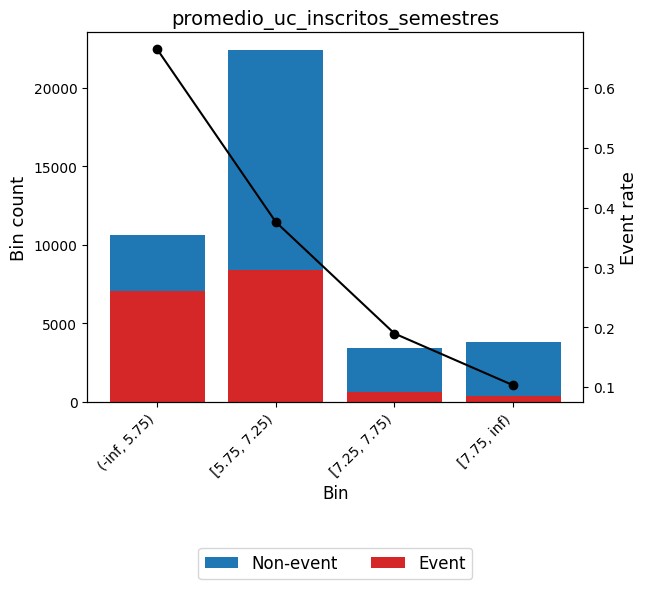

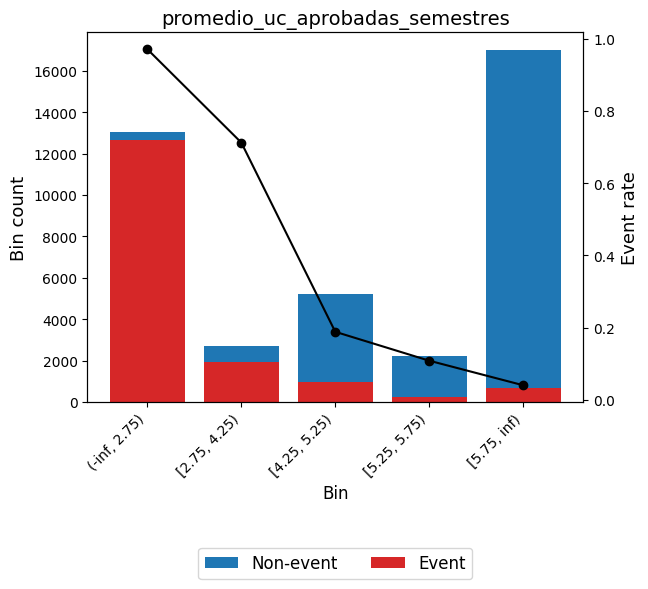

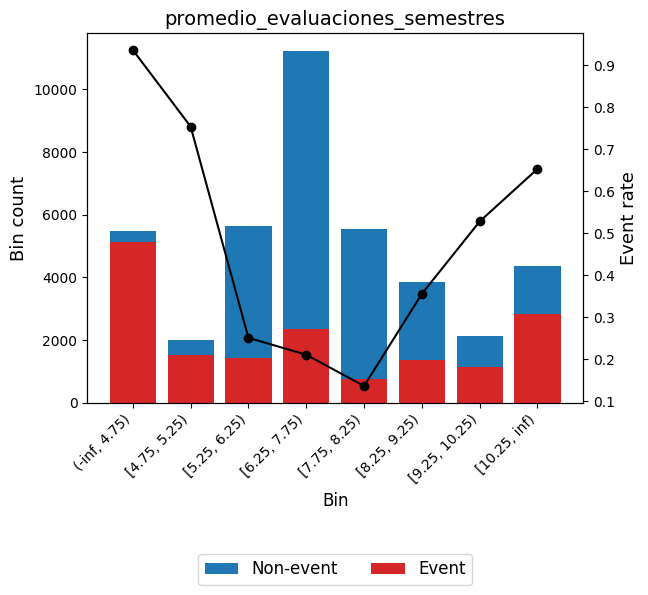

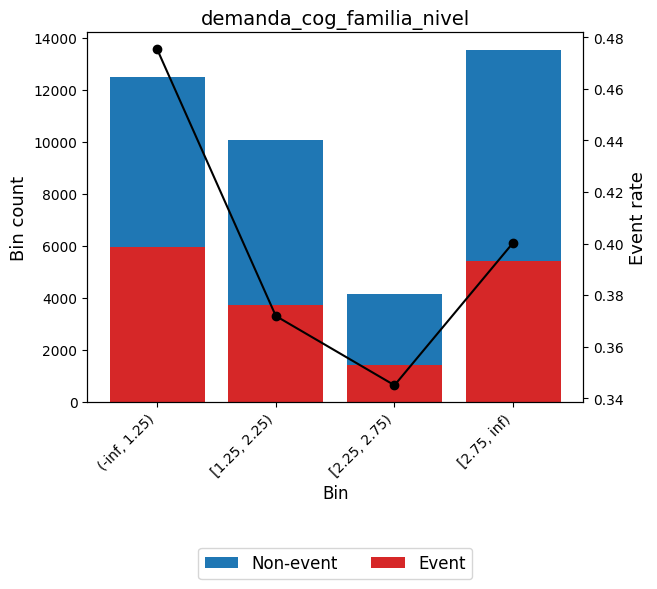

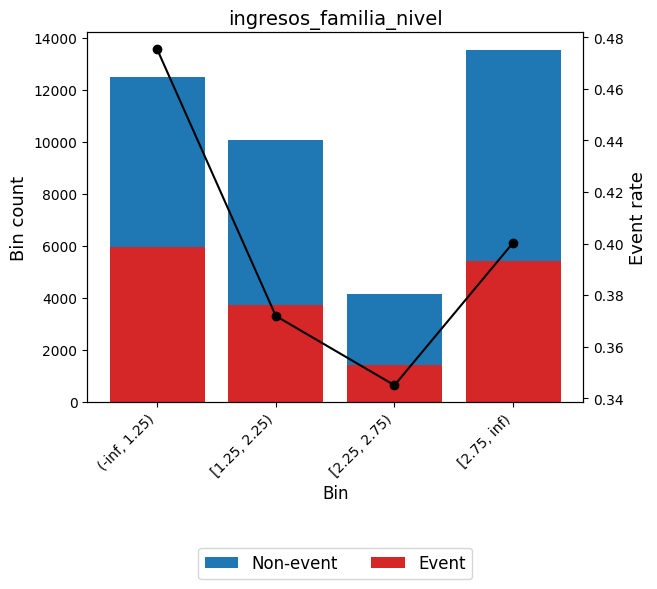

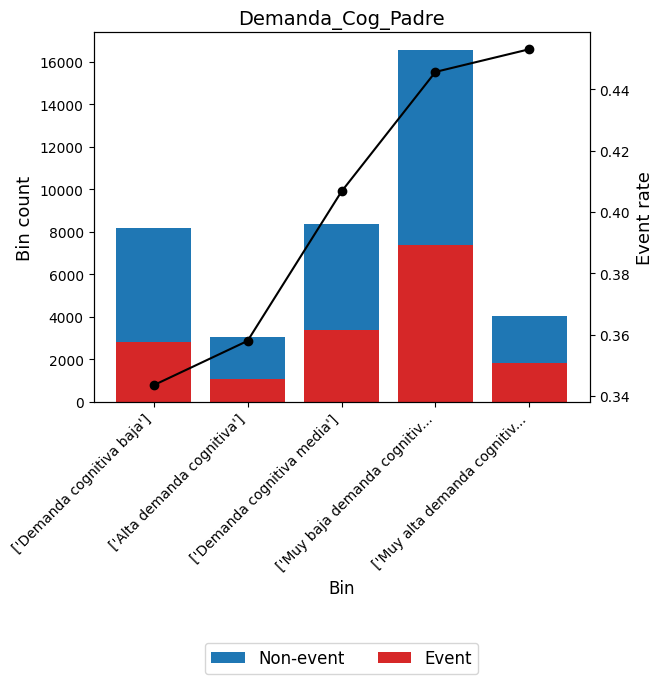

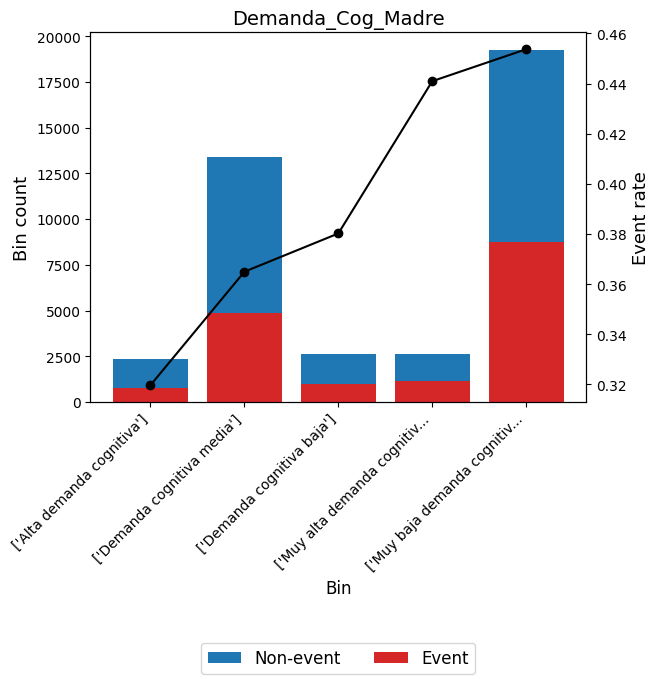

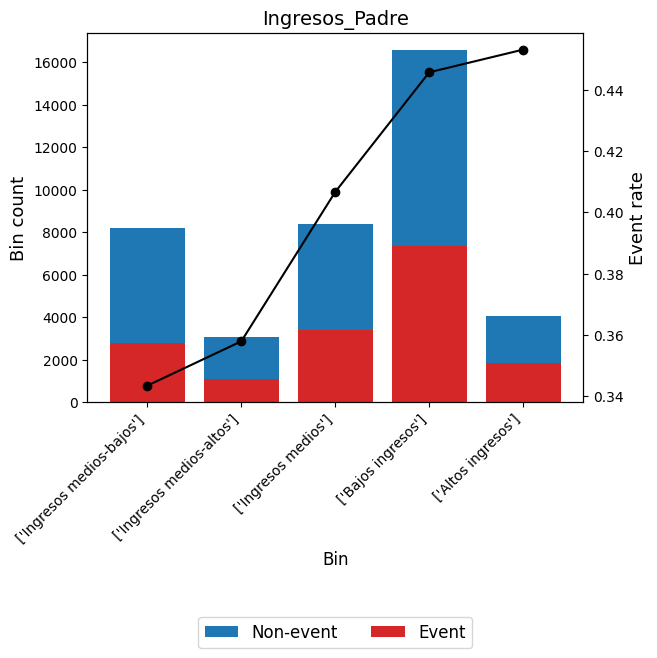

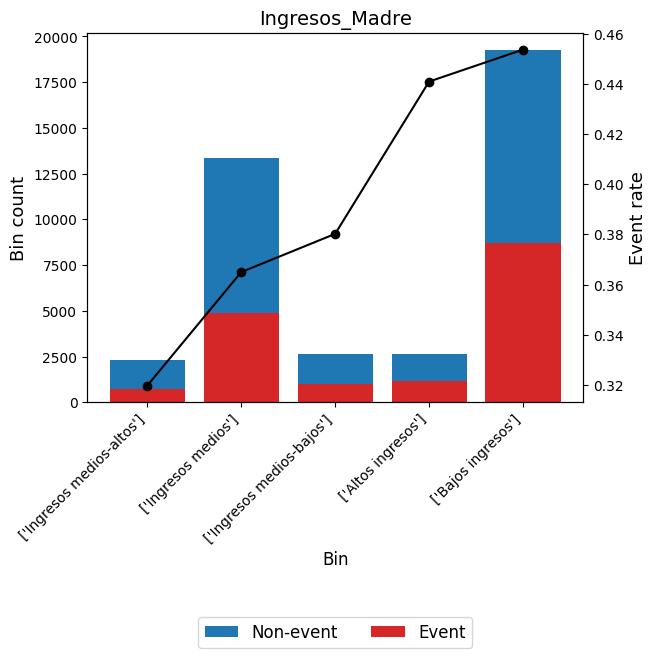

,variable,tipo,iv
0,promedio_uc_aprobadas_semestres,numerical,5.084714
1,uc_aprobadas_segundo_semestre,numerical,5.045424
2,promedio_notas_semestres,numerical,4.334500
3,uc_aprobadas_primer_semestre,numerical,4.334347
4,nota_promedio_primer_semestre,numerical,3.571563
5,cant_eval_segundo_semestre,numerical,1.689334
6,promedio_evaluaciones_semestres,numerical,1.649713
7,cant_eval_primer_semestre,numerical,1.607963
8,matricula_al_dia,categorical,1.420947
9,posee_beca,categorical,0.973717


In [12]:
calcular_bivariado_iv(dataset_binario, 'es_desercion', variables_to_iv)
